<h2>Task : Predict Future Stock Prices (Short-Term)

Objective:


Use historical stock data to predict the next day&#39;s closing price.

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,r2_score,mean_squared_error


Dataset:


Stock market data from Yahoo Finance (retrieved using the yfinance Python library)

In [2]:
# Download APPLE's Historic data.
df = yf.download("AAPL",start='2025-01-01',end='2026-01-01')

[*********************100%***********************]  1 of 1 completed


In [3]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2025-01-02,242.301926,247.518596,240.284814,247.349662,55740700
2025-01-03,241.815018,242.629804,240.354349,241.815018,40244100
2025-01-06,243.444611,245.759820,241.656035,242.758989,45045600
2025-01-07,240.672348,243.991141,239.817807,241.437449,40856000
2025-01-08,241.159225,242.162823,238.526055,240.384178,37628900


In [4]:
df.columns

MultiIndex([( 'Close', 'AAPL'),
            (  'High', 'AAPL'),
            (   'Low', 'AAPL'),
            (  'Open', 'AAPL'),
            ('Volume', 'AAPL')],
           names=['Price', 'Ticker'])

In [5]:
# Columns are multiindex form so i set its level at 0 
df.columns = df.columns.get_level_values(0)
df.head()


Price,Close,High,Low,Open,Volume
Date,,,,,
2025-01-02,242.301926,247.518596,240.284814,247.349662,55740700
2025-01-03,241.815018,242.629804,240.354349,241.815018,40244100
2025-01-06,243.444611,245.759820,241.656035,242.758989,45045600
2025-01-07,240.672348,243.991141,239.817807,241.437449,40856000
2025-01-08,241.159225,242.162823,238.526055,240.384178,37628900


<h4> Basis EDA

In [6]:
df.shape

(250, 5)

In [7]:
df.index


DatetimeIndex(['2025-01-02', '2025-01-03', '2025-01-06', '2025-01-07',
               '2025-01-08', '2025-01-10', '2025-01-13', '2025-01-14',
               '2025-01-15', '2025-01-16',
               ...
               '2025-12-17', '2025-12-18', '2025-12-19', '2025-12-22',
               '2025-12-23', '2025-12-24', '2025-12-26', '2025-12-29',
               '2025-12-30', '2025-12-31'],
              dtype='datetime64[s]', name='Date', length=250, freq=None)

In [8]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 250 entries, 2025-01-02 to 2025-12-31
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   250 non-null    float64
 1   High    250 non-null    float64
 2   Low     250 non-null    float64
 3   Open    250 non-null    float64
 4   Volume  250 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 11.7 KB


In [9]:
df.describe()

Price,Close,High,Low,Open,Volume
count,250.000000,250.000000,250.000000,250.000000,2.500000e+02
mean,231.349890,233.833557,228.745396,231.156007,5.417578e+07
std,26.574991,26.312843,26.784552,26.634415,2.337841e+07
min,171.513763,189.339575,168.320644,171.046232,1.791060e+07
25%,209.182636,211.166296,206.993082,209.142795,4.086605e+07
50%,229.226494,231.707152,226.505872,228.967223,4.778135e+07
75%,253.614994,255.542047,250.832889,253.727182,5.723262e+07
max,285.659271,288.084759,282.774617,285.669263,1.843959e+08


In [10]:
# For predicting next day close price shift 'close' to -1

df['next_close'] = df['Close'].shift(-1)
df.head()

Price,Close,High,Low,Open,Volume,next_close
Date,,,,,,
2025-01-02,242.301926,247.518596,240.284814,247.349662,55740700,241.815018
2025-01-03,241.815018,242.629804,240.354349,241.815018,40244100,243.444611
2025-01-06,243.444611,245.759820,241.656035,242.758989,45045600,240.672348
2025-01-07,240.672348,243.991141,239.817807,241.437449,40856000,241.159225
2025-01-08,241.159225,242.162823,238.526055,240.384178,37628900,235.346359


In [11]:
# Drop last row that become Nan
df =df.dropna()

In [12]:
# Iniatialize input features and target
Features = ['Open','High','Low','Volume']

x = df[Features]
y = df['next_close']

<h4> Splitting

In [13]:
# Split Data
x_train,x_test,y_train,y_test = train_test_split(x,y,
                                                 test_size=0.3,   #70% for training,30% for testing
                                                 shuffle=False)    # data seletion must be sequentialy

<h4> Model Training

In [14]:
# Training
lr = LinearRegression()
lr.fit(x_train,y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[0.32,0.32,0.31,0. ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['Open','High','Low','Volume']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,10.36
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,2


<h4> Model Testing

In [15]:
# Prediction
y_pred = lr.predict(x_test)
print(y_pred) 

[235.21479283 236.64704116 237.29568779 237.6268442  240.80111878
 248.80297439 253.13290658 251.61394564 251.64259508 252.70704891
 251.7825246  252.20187899 253.74582331 253.79648556 253.46540326
 254.81108807 254.01779706 254.49620174 253.81419012 249.53552374
 246.11209245 244.68934507 247.42147576 245.41111148 247.39248849
 256.02943871 260.15142053 257.61926328 256.84744298 258.73156608
 263.20825615 265.85522361 266.11007105 268.27706142 271.1007139
 266.02582491 265.99172646 265.93069826 266.54532864 266.44919429
 267.10276944 268.80244968 270.99461814 271.14263078 269.15159986
 265.48449247 265.79977406 264.91097253 267.76128236 265.46089742
 269.84742764 273.673941   274.36908864 274.09161851 275.79578083
 280.68807451 282.30420229 278.92086252 276.47237563 274.63815027
 275.00155953 274.63165788 274.18883233 274.63112047 274.40407469
 270.25109478 271.11676143 268.39713812 269.19084512 269.34640984
 267.96292769 270.19806474 270.96666633 270.01689097 269.94345015]


<h4> Validation

In [16]:
# Evalution
print( " Model Evalution")
mae = mean_absolute_error(y_test,y_pred)

mse = mean_squared_error(y_test,y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test,y_pred)


print('\n Mean absolute Error:')
print(mae)
print('\nRoot mean squared error:')
print(rmse)
print('\n R2 score:')
print(r2)


 Model Evalution

 Mean absolute Error:
3.493374213920349

Root mean squared error:
4.560180691115496

 R2 score:
0.8449323132674175


<h4>Prices Comparison

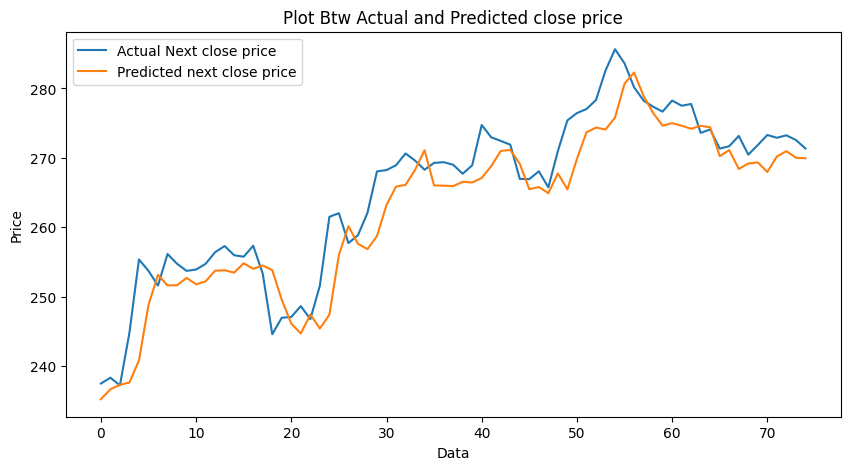

In [17]:
plt.figure(figsize=(10,5))

plt.plot(y_test.values,label='Actual Next close price')
plt.plot(y_pred,label='Predicted next close price')
plt.title('Plot Btw Actual and Predicted close price')
plt.xlabel('Data')
plt.ylabel('Price')
plt.legend()
plt.show()

<h4>Insights

<h5>The graph shows that the close alignment between the actual and predicted lines, together with the good R² score that is 0.8, indicates that the model is effective at forecasting the next-day closing price.
This suggests that the selected features (Open, High, Low, and Volume) are useful for predicting the next-day closing price and that the model performs well on unseen data.

<h3>Takeaways

Time series data handling.

Regression modeling.

Data fetching using APIs (yfinance).

Plotting predictions vs real data.